In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import contextily as cx
import xgboost as xgb
import shap
import statsmodels.api as sm
from scipy.stats import pearsonr, spearmanr
from scipy.stats import ttest_ind
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.preprocessing import RobustScaler
from linearmodels.panel import PanelOLS
from linearmodels import RandomEffects
from statsmodels.stats.outliers_influence import variance_inflation_factor

C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Add SHELDUS, Census, PEP, SVI, and NRI (FEMA Disaster Index) data

In [2]:
data_path = r"F:/LongMig2025/data/"
SHELDUS = pd.read_csv(data_path + "SHELDUS/ORIGINAL.csv")
state   = gpd.read_file(data_path + "Census/usstate/cb_2018_us_state_500k.shp").to_crs('ESRI:102003')
county  = gpd.read_file(data_path + "Census/maincounty/us_conu_county.shp").to_crs('ESRI:102003')
df_pep_2010 = pd.read_csv(data_path + "PEP/co-est2010-alldata.csv", encoding='latin-1')
df_pep_2020 = pd.read_csv(data_path + "PEP/co-est2020-alldata.csv", encoding='latin-1')
SVI_10  = pd.read_csv(data_path + "SVI/SVI_2010_US_county.csv")

SVI_10['FIPS'] = SVI_10['FIPS'].astype("str").str.rjust(5,"0")
state   = state[~state["NAME"].isin(["Alaska","Hawaii","Puerto Rico",
                                   "American Samoa","United States Virgin Islands",
                                   "Guam","Commonwealth of the Northern Mariana Islands"])]
NRI     = pd.read_csv(data_path + "NRI/NRI_Table_Counties/NRI_Table_Counties.csv")

### Add Employment data, Population Density data, JanuaryTemp, JulyTemp, and House Price data

In [108]:
# Employment = pd.read_csv(data_path + "Unemployment.csv")
PopDensity = pd.read_csv(data_path + "POPDen/2010/PopDensity2010.csv")
# HPI        = pd.read_csv(data_path + "HPI/hpi_master.csv")
house_price= pd.read_csv(data_path + "Zillow/County_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv")
# GDP        = pd.read_csv(data_path + "GDP/CAGDP1_ALL_AREAS_2001_2023.csv",  encoding='latin1')
TJan    = pd.read_csv(data_path + "PRISM/Tmean_Jan_All.csv")
TJuly   = pd.read_csv(data_path + "PRISM/Tmean_July_All.csv")
LAI     = pd.read_csv(data_path + "LAI/LAI_W.csv")
# LAI     = pd.read_csv(data_path + "LAI/LAI.csv")

### Process of PEP data

In [4]:
df_pep_2010["state"] = df_pep_2010["STATE"].astype('int64').astype('str').str.rjust(2, "0")
df_pep_2010["county"] = df_pep_2010["COUNTY"].astype('int64').astype('str').str.rjust(3, "0")
df_pep_2010["FIPS"] = df_pep_2010["state"] + df_pep_2010["county"]

df_pep_2020["state"] = df_pep_2020["STATE"].astype('int64').astype('str').str.rjust(2, "0")
df_pep_2020["county"] = df_pep_2020["COUNTY"].astype('int64').astype('str').str.rjust(3, "0")
df_pep_2020["FIPS"] = df_pep_2020["state"] + df_pep_2020["county"]

In [5]:
df_pep_0120 = pd.merge(df_pep_2010,df_pep_2020,on="FIPS")

### Process of FEMA Disaster Index
Disaster selections: Drought, Heat Wave

Assessing population change in the CONUS from 2000 to 2020 in relation to climate hazard exposure

In [6]:
NRI_CONUS = NRI[~NRI["STATEFIPS"].isin([2, 15, 72, 78, 66, 60, 69])].reset_index(drop=True)
NRI_CONUS["FIPS"] = NRI_CONUS["NRI_ID"].str.extract('(\d{5})')
columns_sel_NRI = ["FIPS","STATEABBRV","STATEFIPS","COUNTY","RISK_SCORE","RISK_RATNG","RISK_SPCTL",
#                     "CWAV_EVNTS","CWAV_AFREQ","CWAV_RISKS","CWAV_RISKR", #Cold Wave
                    "DRGT_EVNTS","DRGT_AFREQ","DRGT_RISKS","DRGT_RISKR", #Drought
                    "HWAV_EVNTS","HWAV_AFREQ","HWAV_RISKS","HWAV_RISKR"] #Heat Wave
#                     "HRCN_EVNTS","HRCN_AFREQ","HRCN_RISKS","HRCN_RISKR", #Hurricane
#                     "RFLD_EVNTS","RFLD_AFREQ","RFLD_RISKS","RFLD_RISKR", #Riverine Flooding
#                     "WFIR_EVNTS","WFIR_AFREQ","WFIR_RISKS","WFIR_RISKR", #Wildfire
#                     "WNTW_EVNTS","WNTW_AFREQ","WNTW_RISKS","WNTW_RISKR"] #Winter Weather
                   # EVNTS:Number of Events, AFREQ:Annualized Frequency,RISKS/R: RISK Score/Rating
NRI_CONUS = NRI_CONUS[columns_sel_NRI]        

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\xiang11\AppData\Local\Temp\ipykernel_46788\3763222493.py:2: SyntaxWarning: invalid escape sequence '\d'
  NRI_CONUS["FIPS"] = NRI_CONUS["NRI_ID"].str.extract('(\d{5})')


### Process of Pop Density

In [7]:
PopDensity_CONUS = PopDensity[~(PopDensity["STATE"] == 2)]
PopDensity_CONUS = PopDensity_CONUS[~(PopDensity_CONUS["STATE"] == 15)]
PopDensity_CONUS["FIPS"] = PopDensity_CONUS['GEOID10'].astype(str).str.rjust(5,"0")
PopDensity_CONUS_sel = PopDensity_CONUS[["FIPS","POPDENS10"]]

### Process of House Price

In [8]:
house_price['StateCodeFIPS'] = house_price['StateCodeFIPS'].astype(str).str.zfill(2)
house_price['MunicipalCodeFIPS'] = house_price['MunicipalCodeFIPS'].astype(str).str.zfill(3)
house_price['FIPS'] = house_price['StateCodeFIPS'] + house_price['MunicipalCodeFIPS']

monthly_columns = [col for col in house_price.columns if '-' in col and len(col.split('-')[0]) == 4]

monthly_data = house_price[['FIPS'] + monthly_columns].copy()
monthly_data = monthly_data.melt(id_vars=['FIPS'], var_name='date', value_name='price')
monthly_data['date'] = pd.to_datetime(monthly_data['date'])
monthly_data['year'] = monthly_data['date'].dt.year

annual_prices = monthly_data.groupby(['FIPS', 'year'])['price'].mean().reset_index()

annual_prices_pivot = annual_prices.pivot(index='FIPS', columns='year', values='price').reset_index()

def calculate_ratio(row):
    available_years = row[annual_price_columns].dropna()
    if len(available_years) > 1:
        first_year = available_years.index[0]
        last_year = available_years.index[-1]
        return ((available_years[last_year] - available_years[first_year]) / available_years[first_year]) * 100
    return None 

def calculate_average(row):
    available_years = row[annual_price_columns].dropna()
    if len(available_years) > 0:
        return available_years.mean()
    return None  # Return None if no data is available

annual_price_columns = [col for col in annual_prices_pivot.columns if isinstance(col, int)]

annual_prices_pivot['ratio_HP'] = annual_prices_pivot.apply(calculate_ratio, axis=1)
annual_prices_pivot['average_HP'] = annual_prices_pivot.apply(calculate_average, axis=1)

annual_prices_pivot_cleaned = annual_prices_pivot.dropna(subset=annual_price_columns, how='all')

non_conus_fips_prefixes = ['02', '15', '60', '66', '69', '72', '78']  # Alaska, Hawaii, and island territories

annual_prices_pivot_cleaned['FIPS'] = annual_prices_pivot_cleaned['FIPS'].astype(str)
conus_annual_prices = annual_prices_pivot_cleaned[
    ~annual_prices_pivot_cleaned['FIPS'].str[:2].isin(non_conus_fips_prefixes)
]

### Process of Amenity data

In [9]:
TJan["FIPS"]  = TJan["FIPS"].astype(str).str.rjust(5,"0")
TJuly["FIPS"] = TJuly["FIPS"].astype(str).str.rjust(5,"0")
TJan_sel  = TJan[["FIPS","MEAN"]].rename(columns={"MEAN":"TJAN"})
TJuly_sel = TJuly[["FIPS","MEAN"]].rename(columns={"MEAN":"TJULY"})
T_sel = pd.merge(TJan_sel,TJuly_sel,on="FIPS")

### Process of Location Affordability Index (LAI)

In [91]:
LAI

,FIPS,FREQUENCY,MEAN_hh_type1_h
0,01001,32,57.534006
1,01003,93,55.312628
2,01005,23,68.394315
3,01007,15,55.706191
4,01009,35,57.610451
...,...,...,...
3216,72145,37,0.000000
3217,72147,6,0.000000
3218,72149,17,0.000000
3219,72151,23,0.000000


In [110]:
LAI["FIPS"]  = LAI["FIPS"].astype(str).str.rjust(5,"0")
LAI = LAI.rename(columns={
    "W_LAI":"W_HT_LAI"
#     "MEAN_hh_type1_h":"W_HT_LAI"
})
LAI = LAI[["FIPS","W_HT_LAI"]]
non_conus_fips_prefixes = ['02', '15', '60', '66', '69', '72', '78']  # Alaska, Hawaii, and island territories
LAI = LAI[
    ~LAI['FIPS'].str[:2].isin(non_conus_fips_prefixes)
]

### Process of SHELDUS

In [11]:
SHELDUS['County FIPS'] = SHELDUS['County FIPS'].str.replace("'", "")
SHELDUS_0020 = SHELDUS[(SHELDUS["Year"]<2021) & (SHELDUS["Year"]>2000)]

In [12]:
SHELDUS_0020 = SHELDUS_0020[~((SHELDUS_0020['Year'] == 2000) & (SHELDUS_0020['Month'] <= 6))]
SHELDUS_0020 = SHELDUS_0020[~((SHELDUS_0020['Year'] == 2020) & (SHELDUS_0020['Month'] >= 7))]

In [13]:
SHELDUS_0020["StateID"] = SHELDUS_0020["County FIPS"].astype(str).str[:2]
SHELDUS_0020 = SHELDUS_0020[~SHELDUS_0020["StateID"].isin(non_conus_fips_prefixes)]
SHELDUS_0020_dis = SHELDUS_0020.groupby(["Hazard"]).agg({"PropertyDmg(ADJ 2020)":"sum","Fatalities":"sum","Injuries":"sum"}).reset_index()

In [14]:
SHELDUS_0020_dis.sort_values(by="PropertyDmg(ADJ 2020)",ascending=False)

,Hazard,PropertyDmg(ADJ 2020),Fatalities,Injuries
4,Flooding,2.056574e+11,1648.020,1387.000
8,Hurricane/Tropical Storm,1.759030e+11,1215.980,1300.010
12,Tornado,3.784049e+10,1504.000,19077.000
15,Wildfire,3.218132e+10,296.000,1619.960
6,Hail,2.999533e+10,3.000,620.000
16,Wind,1.825596e+10,973.315,3993.930
17,Winter Weather,1.136860e+10,648.995,2833.035
11,Severe Storm/Thunder Storm,5.431994e+09,303.500,2387.000
3,Earthquake,4.256910e+09,7.990,223.000
9,Landslide,3.151915e+09,183.960,300.010


In [15]:
SHELDUS_0020_dis.sort_values(by="Fatalities",ascending=False)

,Hazard,PropertyDmg(ADJ 2020),Fatalities,Injuries
7,Heat,2.999983e+07,2270.370,13327.930
4,Flooding,2.056574e+11,1648.020,1387.000
12,Tornado,3.784049e+10,1504.000,19077.000
8,Hurricane/Tropical Storm,1.759030e+11,1215.980,1300.010
16,Wind,1.825596e+10,973.315,3993.930
1,Coastal,3.384633e+08,966.990,831.250
17,Winter Weather,1.136860e+10,648.995,2833.035
10,Lightning,9.664669e+08,624.000,3598.000
11,Severe Storm/Thunder Storm,5.431994e+09,303.500,2387.000
15,Wildfire,3.218132e+10,296.000,1619.960


In [16]:
SHELDUS_0020_sel = SHELDUS_0020[SHELDUS_0020["Hazard"].isin(['Flooding','Hurricane/Tropical Storm','Wildfire','Heat','Tornado'])].reset_index(drop=True)

In [17]:
SHELDUS_0020_hurricane = SHELDUS_0020_sel[SHELDUS_0020_sel["Hazard"]=="Hurricane/Tropical Storm"].reset_index()
SHELDUS_0020_flooding  = SHELDUS_0020_sel[SHELDUS_0020_sel["Hazard"]=="Flooding"].reset_index()

In [18]:
hurricane_induced_floods = pd.merge(
    SHELDUS_0020_flooding, 
    SHELDUS_0020_hurricane, 
    on=['County FIPS', 'Year', 'Month'],
    suffixes=('_flood', '_hurricane')
)
flood_indices = hurricane_induced_floods['index_flood']

In [19]:
SHELDUS_0020_sel.loc[flood_indices, 'Hazard'] = 'Hurricane/Tropical Storm'

In [20]:
SHELDUS_0020_use = SHELDUS_0020_sel[(SHELDUS_0020_sel["Fatalities"]!=0)|(SHELDUS_0020_sel["Injuries"]!=0)|(SHELDUS_0020_sel["PropertyDmgPerCapita(ADJ 2020)"]>1)]
SHELDUS_0020_use_group = SHELDUS_0020_use.groupby(["County FIPS","Hazard","Year"]).agg({"Month":"count",
                                                                                        "Fatalities":"sum",
                                                                                        "Injuries":"sum",
                                                                                        "PropertyDmg(ADJ 2020)":"sum",
                                                                                        "PropertyDmgPerCapita(ADJ 2020)":"mean"}).reset_index()
SHELDUS_0020_use_group = SHELDUS_0020_use_group.rename(columns={"Month":"count"})

SHELDUS_0020_use_group["Loss"] = SHELDUS_0020_use_group["Fatalities"] * 11600000 + SHELDUS_0020_use_group["Injuries"] / 10 * 11600000 + SHELDUS_0020_use_group["PropertyDmg(ADJ 2020)"]

df_20_years_by_county = SHELDUS_0020_use_group.groupby(['County FIPS',"Hazard"]).agg({"count":"sum",
                                                                                        "Fatalities":"sum",
                                                                                        "Injuries":"sum",
                                                                                        "PropertyDmg(ADJ 2020)":"sum",
                                                                                        "PropertyDmgPerCapita(ADJ 2020)":"mean",
                                                                                        "Loss":"sum"}).reset_index()


In [21]:
df_20_years_by_county = df_20_years_by_county.rename(columns={"count":"frequency"})

In [22]:
df_20_years_by_county

,County FIPS,Hazard,frequency,Fatalities,Injuries,PropertyDmg(ADJ 2020),PropertyDmgPerCapita(ADJ 2020),Loss
0,01001,Flooding,5,0.0,0.0,2056422.32,5.155596,2.056422e+06
1,01001,Heat,2,2.0,17.0,0.00,0.000000,4.292000e+07
2,01001,Hurricane/Tropical Storm,2,0.0,0.0,348956.00,3.644830,3.489560e+05
3,01001,Tornado,7,3.0,57.0,16607999.09,49.857632,1.175280e+08
4,01003,Flooding,6,2.0,1.0,32935300.94,18.341990,5.729530e+07
...,...,...,...,...,...,...,...,...
6857,56043,Flooding,4,0.0,0.0,615508.45,18.610973,6.155084e+05
6858,56043,Tornado,2,0.0,0.0,105022.37,6.249810,1.050224e+05
6859,56043,Wildfire,1,0.0,0.0,25283.80,3.239440,2.528380e+04
6860,56045,Flooding,8,0.0,0.0,602898.78,13.979221,6.028988e+05


In [41]:
Floods = df_20_years_by_county[df_20_years_by_county["Hazard"]=="Flooding"]
Floods = Floods.rename(columns={"frequency":"Flood_Frequency","PropertyDmgPerCapita(ADJ 2020)":"Flood_Loss"})
Hurricane = df_20_years_by_county[df_20_years_by_county["Hazard"]=="Hurricane/Tropical Storm"]
Hurricane = Hurricane.rename(columns={"frequency":"Hurricane_Frequency","PropertyDmgPerCapita(ADJ 2020)":"Hurricane_Loss"})
Wildfire = df_20_years_by_county[df_20_years_by_county["Hazard"]=="Wildfire"]
Wildfire = Wildfire.rename(columns={"frequency":"Wildfire_Frequency","PropertyDmgPerCapita(ADJ 2020)":"Wildfire_Loss"})
Tornado = df_20_years_by_county[df_20_years_by_county["Hazard"]=="Tornado"]
Tornado = Tornado.rename(columns={"frequency":"Tornado_Frequency","PropertyDmgPerCapita(ADJ 2020)":"Tornado_Loss"})
Heat = df_20_years_by_county[df_20_years_by_county["Hazard"]=="Heat"]
Heat = Heat.rename(columns={"frequency":"Heat_Frequency","PropertyDmgPerCapita(ADJ 2020)":"Heat_Loss"})
Floods["Flood_Occur"] = 1
Hurricane["Hurricane_Occur"] = 1
Wildfire["Wildfire_Occur"] = 1
Tornado["Tornado_Occur"] = 1
Heat["Heat_Occur"] = 1
Floods = Floods[["County FIPS","Flood_Frequency","Flood_Loss","Flood_Occur"]]
Hurricane = Hurricane[["County FIPS","Hurricane_Frequency","Hurricane_Loss","Hurricane_Occur"]]
Wildfire = Wildfire[["County FIPS","Wildfire_Frequency","Wildfire_Loss","Wildfire_Occur"]]
Tornado = Tornado[["County FIPS","Tornado_Frequency","Tornado_Loss","Tornado_Occur"]]
Heat = Heat[["County FIPS","Heat_Frequency","Heat_Loss","Heat_Occur"]]

In [42]:
Disaster = pd.merge(Floods,Hurricane,on="County FIPS",how='outer')
Disaster = pd.merge(Disaster,Wildfire,on="County FIPS",how='outer')
Disaster = pd.merge(Disaster,Tornado,on="County FIPS",how='outer')
Disaster = pd.merge(Disaster,Heat,on="County FIPS",how='outer')

In [43]:
Disaster = Disaster.fillna(0)

### Compute Net Migration Rate (NMR)

In [26]:
correct_netmig_columns = []
for year in range(2001, 2021):
    column_name_x = f'RNETMIG{year}_x'
    column_name_y = f'RNETMIG{year}_y'
    column_name = f'RNETMIG{year}'
    if column_name in df_pep_0120.columns:
        correct_netmig_columns.append(column_name)
    elif column_name_x in df_pep_0120.columns:
        correct_netmig_columns.append(column_name_x)
    elif column_name_y in df_pep_0120.columns:
        correct_netmig_columns.append(column_name_y)

In [27]:
df_pep_0120["NetMigrationRateTotal"] = df_pep_0120[correct_netmig_columns].mean(axis=1)
df_pep_0120_used = df_pep_0120[['FIPS','STNAME_x', 'CTYNAME_x', 'NetMigrationRateTotal']]

In [28]:
df_pep_0120.to_csv(data_path+"pep.csv")

In [29]:
df_NMR = pd.merge(df_pep_0120_used,county,on="FIPS",how="inner")
gdf_NMR = gpd.GeoDataFrame(df_NMR,geometry="geometry")

<Figure size 1000x800 with 0 Axes>

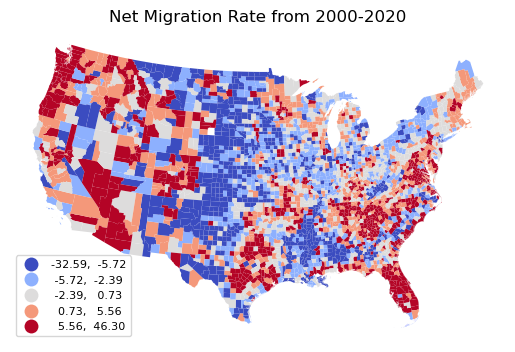

In [30]:
plt.figure(figsize=(10, 8))
gdf_NMR.plot(column="NetMigrationRateTotal",cmap="coolwarm",
             scheme="quantiles",
#              scheme='userdefined',classification_kwds={'bins':[-500,-100,-50,-25,-10,-0.1,0,0.1,10,25,50,100,500]},
             legend=True,legend_kwds={
        "fontsize": 8,  # Adjust font size for smaller text
        "loc": "lower left",  # Position the legend
    })
plt.title("Net Migration Rate from 2000-2020")
plt.axis('off')
plt.show()

### Map the disaster risk

In [42]:
df_NRI = pd.merge(NRI_CONUS,county,on="FIPS",how="inner")
gdf_NRI = gpd.GeoDataFrame(df_NRI,geometry="geometry")

In [43]:
risk_columns = [col for col in gdf_NRI.columns if 'RISKS' in col]

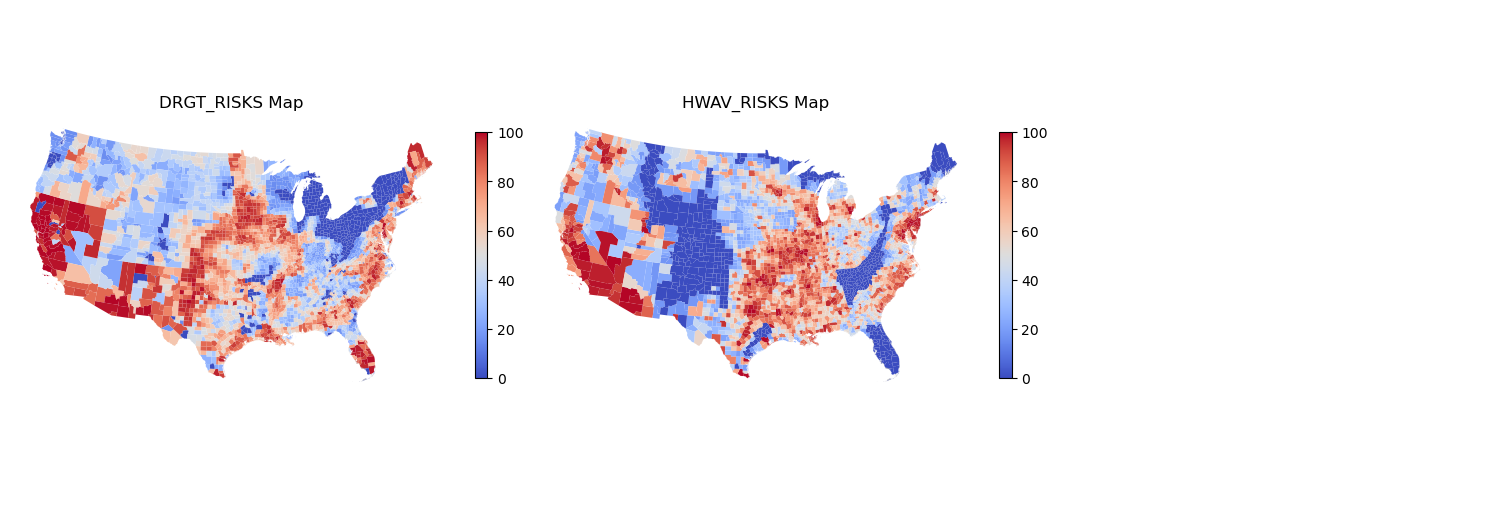

In [44]:
# Create subplots for the maps
num_risks = len(risk_columns)
cols = 3  # Number of columns for the subplots
rows = (num_risks + cols - 1) // cols  # Calculate rows based on the number of risks

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows), constrained_layout=True)

# Flatten axes for easy iteration
axes = axes.flatten()

# Plot each map in a subplot
for i, risk in enumerate(risk_columns):
    gdf_NRI.plot(
        column=risk,
        cmap='coolwarm',
        legend=True,
        ax=axes[i],
        legend_kwds={'shrink': 0.5},  # Shrink legend to fit subplot
    )
    axes[i].set_title(f'{risk} Map', fontsize=12)
    axes[i].axis('off')  # Turn off axis

# Turn off unused axes
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

# Show the figure
plt.show()

### Map the frequency and loss

In [31]:
df_disaster = pd.merge(df_20_years_by_county,county,left_on="County FIPS",right_on="FIPS",how="inner")
gdf_disaster = gpd.GeoDataFrame(df_disaster,geometry="geometry")

C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\mapclassify\classifiers.py:1653: UserWarning: Not enough unique values in array to form 5 classes. Setting k to 4.
  self.bins = quantile(y, k=k)
C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\mapclassify\classifiers.py:1653: UserWarning: Not enough unique values in array to form 5 classes. Setting k to 4.
  self.bins = quantile(y, k=k)
C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\mapclassify\classifiers.py:1653: UserWarning: Not enough unique values in array to form 5 classes. Setting k to 3.
  self.bins = quantile(y, k=k)
C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\mapclassify\classifiers.py:1653: UserWarning: Not enough unique values in array to form 5 classes. Setting k to 2.
  self.bins = quantile(y, k=k)


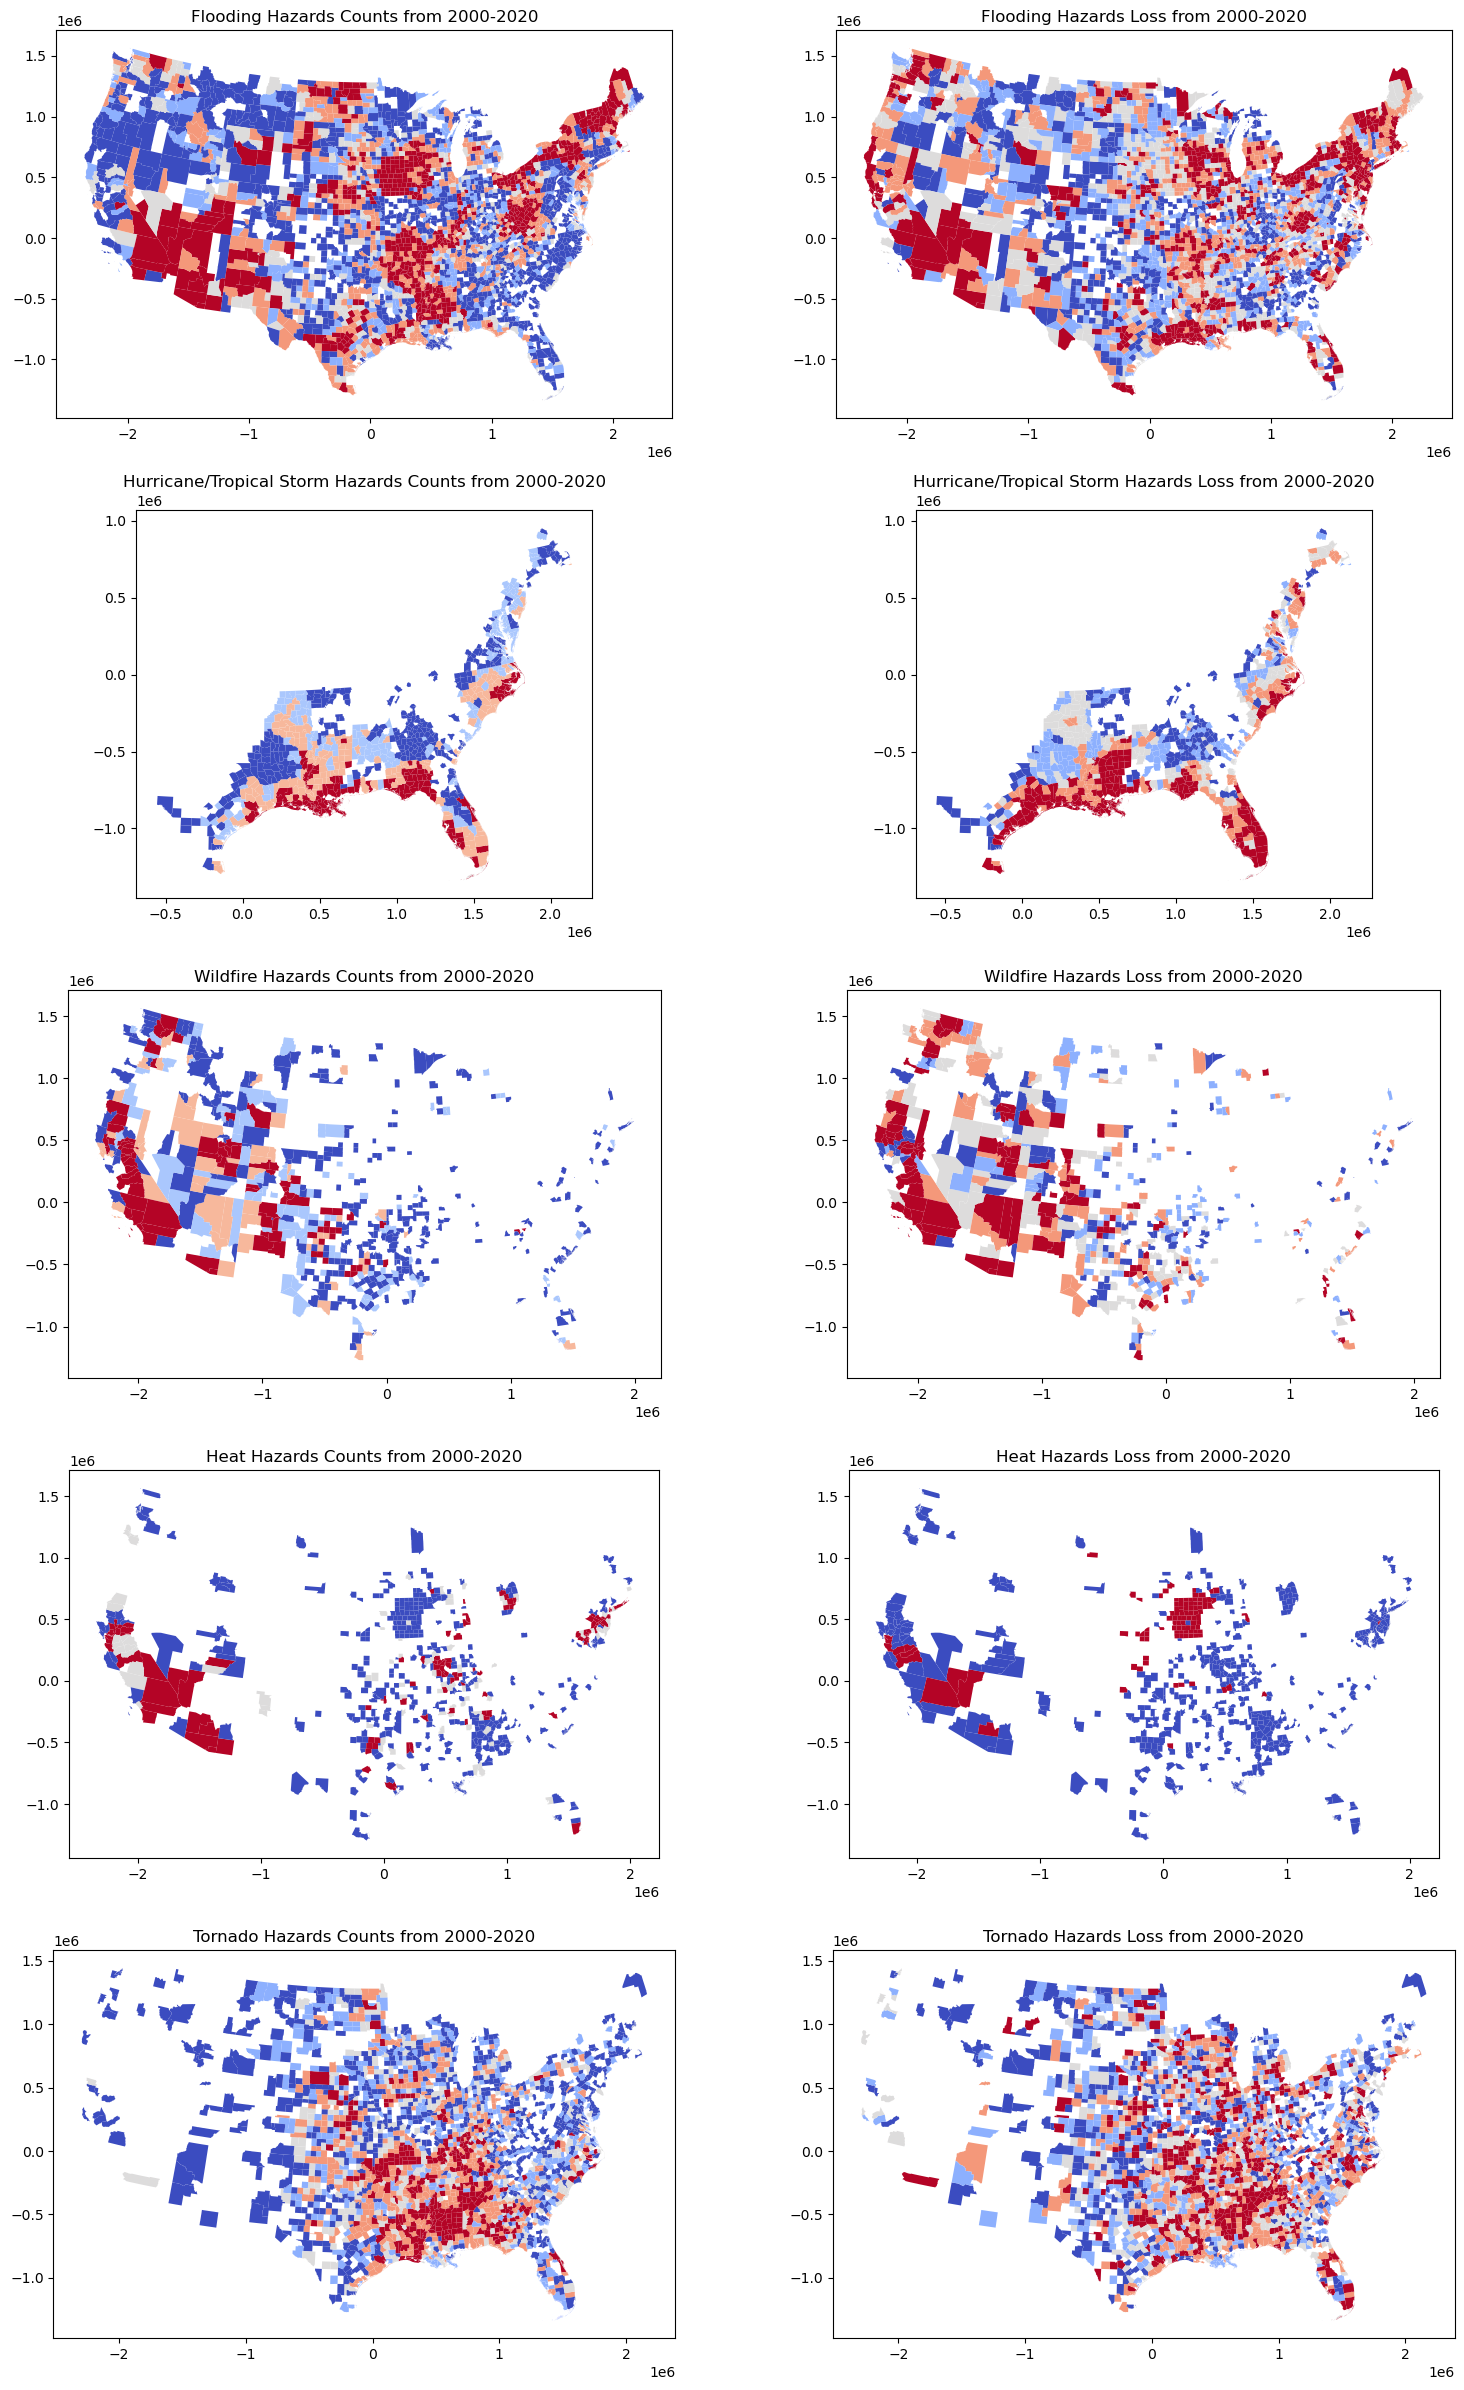

In [33]:
fig, axes = plt.subplots(5,2,figsize=(16,24))
list_disaster = ['Flooding','Hurricane/Tropical Storm','Wildfire','Heat','Tornado']
for i in range(5):
    use_df_disaster = gdf_disaster[gdf_disaster["Hazard"] == str(list_disaster[i])]
#     print(use_df_disaster.head())
    use_df_disaster.plot(column="frequency",cmap="coolwarm",scheme='quantiles',
#                          classification_kwds={'bins':[1,3,5,10,20,50]},
                         ax=axes[i,0])
    use_df_disaster.plot(column="PropertyDmg(ADJ 2020)",cmap="coolwarm",scheme="quantiles",
#                          ,legend=True,
                         ax=axes[i,1])
    axes[i,0].set_title(f"{list_disaster[i]} Hazards Counts from 2000-2020")
    axes[i,1].set_title(f"{list_disaster[i]} Hazards Loss from 2000-2020")
plt.tight_layout()
plt.show()

### Combine each dataset

In [111]:
Regression_data = pd.DataFrame()
Regression_data = df_pep_0120
Regression_data = pd.merge(Regression_data,Disaster,left_on="FIPS",right_on="County FIPS",how="outer")
Regression_data = pd.merge(Regression_data,LAI,left_on="FIPS",right_on="FIPS",how="inner")
# Regression_data = pd.merge(Regression_data,Hurricane,left_on="FIPS",right_on="County FIPS",how="outer")
# Regression_data = pd.merge(Regression_data,Wildfire,left_on="FIPS",right_on="County FIPS",how="outer")
# Regression_data = pd.merge(Regression_data,Tornado,left_on="FIPS",right_on="County FIPS",how="outer")
# Regression_data = pd.merge(Regression_data,Heat,left_on="FIPS",right_on="County FIPS",how="outer")
Regression_data = pd.merge(Regression_data,SVI_10,on="FIPS",how="inner")
Regression_data = pd.merge(Regression_data,NRI_CONUS,on="FIPS",how="inner")
# Regression_data = pd.merge(Regression_data,unemployment_rate_pivot,on="FIPS",how="inner")
Regression_data = pd.merge(Regression_data,PopDensity_CONUS_sel,on="FIPS",how="inner")
Regression_data = pd.merge(Regression_data,conus_annual_prices,on="FIPS",how="inner")
# Regression_data = pd.merge(Regression_data,GDP_final_data,on="FIPS",how="inner")
Regression_data = pd.merge(Regression_data,T_sel,on="FIPS",how="inner")

In [112]:
Regression_data = Regression_data.fillna(0)

In [113]:
used_list = [
    "FIPS","NetMigrationRateTotal",#PEP
    "Flood_Frequency","Flood_Loss",
    "Hurricane_Frequency","Hurricane_Loss",
    "Wildfire_Frequency","Wildfire_Loss",
    "Tornado_Frequency","Tornado_Loss",
    "Heat_Frequency","Heat_Loss",
    "E_P_POV","E_P_UNEMP","E_P_PCI","E_P_NOHSDIP","P_AGE65","P_AGE17","P_SNGPRNT",
    "P_MINORITY","E_P_LIMENG","E_P_MUNIT","E_P_MOBILE","E_P_CROWD","E_P_NOVEH","P_GROUPQ", #SVI
    "POPDENS10",#POP DENSITY
    "W_HT_LAI",#LAI
    "ratio_HP",#House Price
    'TJAN', 'TJULY' #Amenity
]
standard_list = [
    "Flood_Frequency","Flood_Loss",
    "Hurricane_Frequency","Hurricane_Loss",
    "Wildfire_Frequency","Wildfire_Loss",
    "Tornado_Frequency","Tornado_Loss",
    "Heat_Frequency","Heat_Loss",
    "E_P_POV","E_P_UNEMP","E_P_PCI","E_P_NOHSDIP","P_AGE65","P_AGE17","P_SNGPRNT",
    "P_MINORITY","E_P_LIMENG","E_P_MUNIT","E_P_MOBILE","E_P_CROWD","E_P_NOVEH","P_GROUPQ", #SVI
    "POPDENS10",#POP DENSITY
    "W_HT_LAI",#LAI
    "ratio_HP",#House Price
    'TJAN', 'TJULY']

name_list = [
    "FIPS","NMR",
    "Flood_Frequency","Flood_Loss",
    "Hurricane_Frequency","Hurricane_Loss",
    "Wildfire_Frequency","Wildfire_Loss",
    "Tornado_Frequency","Tornado_Loss",
    "Heat_Frequency","Heat_Loss",
    "%BelowPoverty","%Unemployed","PerCapitaIncome","%NoHighSchoolDiploma25+","%Age65+",
    "%Age18-","%Single-parent household","%Minority","%Age5+LessThanWellEnglish",
    "%Multi-Unit House","%MobileHome","%HousePop>Room","%NoVehicleHousehold","%GroupQuarters",
    "Pop Density",
    "Affordability",
    "%Change of House Price",
    "Jan Temp","July Temp"
]

In [70]:
# used_list = [
#     "FIPS","NetMigrationRateTotal",#PEP
#     "Flood_Frequency","Flood_Loss",
#     "Hurricane_Frequency","Hurricane_Loss",
#     "Wildfire_Frequency","Wildfire_Loss",
#     "Tornado_Frequency","Tornado_Loss",
#     "Heat_Frequency","Heat_Loss",
#     "E_P_POV","E_P_UNEMP","E_P_PCI","E_P_NOHSDIP","P_AGE65","P_AGE17","P_SNGPRNT",
#     "P_MINORITY","E_P_LIMENG","E_P_MUNIT","E_P_MOBILE","E_P_CROWD","E_P_NOVEH","P_GROUPQ", #SVI
# #     "DRGT_RISKS","HWAV_RISKS",#RISK SCORE
# #     "average_rate_une",#Unemployment
#     "POPDENS10",#POP DENSITY
#     "ratio_HP",#House Price
# #     "ratio_GDP",#GDP
#     'TJAN', 'TJULY' #Amenity
# ]
# standard_list = ["Flood_Frequency",
#     "Hurricane_Frequency",
#     "Wildfire_Frequency","Tornado_Frequency","Heat_Frequency","E_P_POV","E_P_UNEMP","E_P_PCI","E_P_NOHSDIP","P_AGE65","P_AGE17","P_SNGPRNT",
#     "P_MINORITY","E_P_LIMENG","E_P_MUNIT","E_P_MOBILE","E_P_CROWD","E_P_NOVEH","P_GROUPQ", #SVI
# #     "DRGT_RISKS","HWAV_RISKS",#RISK SCORE
# #     "average_rate_une",#Unemployment
    
#     "ratio_HP",#House Price
#     'TJAN', 'TJULY']#GDP
# log_list = ["Flood_Loss","Hurricane_Loss","Wildfire_Loss","Tornado_Loss","Heat_Loss","POPDENS10"]#POP DENSITY

# name_list = [
#     "FIPS","NMR",
#     "Flood_Frequency","log(Flood_Loss)",
#     "Hurricane_Frequency","log(Hurricane_Loss)",
#     "Wildfire_Frequency","log(Wildfire_Loss)",
#     "Tornado_Frequency","log(Tornado_Loss)",
#     "Heat_Frequency","log(Heat_Loss)",
#     "%BelowPoverty","%Unemployed","PerCapitaIncome","%NoHighSchoolDiploma25+","%Age65+",
#     "%Age18-","%Single-parent household","%Minority","%Age5+LessThanWellEnglish",
#     "%Multi-Unit House","%MobileHome","%HousePop>Room","%NoVehicleHousehold","%GroupQuarters",
# #     "Drought Risk","Heat Wave Risk",
#     "logt(Pop Density)","%Change of House Price",
#     "Jan Temp","July Temp"
# ]

In [114]:
from sklearn.preprocessing import StandardScaler
Regression_data_used = Regression_data[used_list]
scaler = StandardScaler()
Regression_data_used[standard_list] = scaler.fit_transform(Regression_data_used[standard_list])
Regression_data_used.columns = name_list

C:\Users\xiang11\AppData\Local\Temp\ipykernel_46788\2702953959.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Regression_data_used[standard_list] = scaler.fit_transform(Regression_data_used[standard_list])


In [77]:
Regression_data_used.to_csv(data_path + "regression_data.csv")

In [135]:
# Regression_data_used.to_csv(data_path + "regression_data.csv")

In [122]:
# Regression_data_used = Regression_data[used_list]
# Regression_data_used[zscore_list] = (Regression_data_used[zscore_list] - Regression_data_used[zscore_list].mean()) / Regression_data_used[zscore_list].std()
# Regression_data_used.columns = name_list

C:\Users\xiang11\AppData\Local\Temp\ipykernel_29000\2705445393.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Regression_data_used[zscore_list] = (Regression_data_used[zscore_list] - Regression_data_used[zscore_list].mean()) / Regression_data_used[zscore_list].std()


### XGBOOST with all factors in Hurricane, Flood, Wildfire

In [98]:
X = Regression_data_used.drop(columns=['NMR', 'FIPS'])
y = Regression_data_used['NMR']

# # Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 500, 1000],
    'subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(xgb.XGBRegressor(objective="reg:squarederror"), param_grid, scoring="neg_mean_squared_error", cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 1000, 'subsample': 0.8}


Mean Squared Error: 20.24245288369626


 99%|===================| 756/763 [00:30<00:00]        

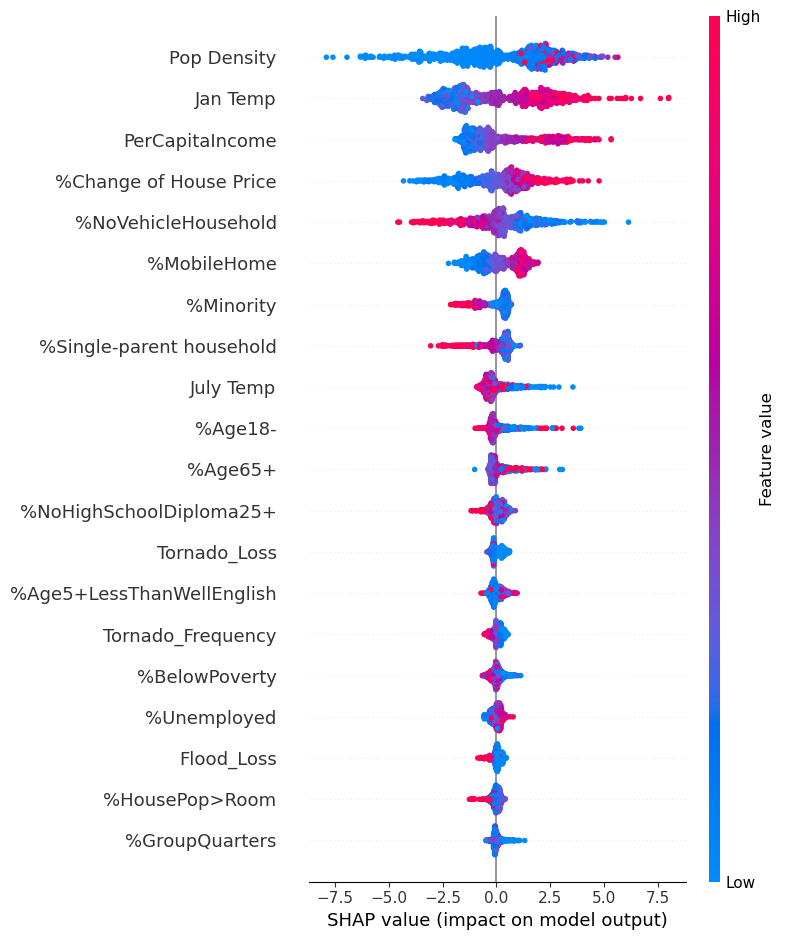

In [148]:
X = Regression_data_used.drop(columns=['NMR', 'FIPS'])
y = Regression_data_used['NMR']

# # Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# # Train an XGBoost regression model
model = xgb.XGBRegressor(objective='reg:squarederror',
                             n_estimators=1000,  
    learning_rate=0.01,
    max_depth=6,  
    subsample=0.8,  
    colsample_bytree=0.8,
    reg_lambda=1,  
    reg_alpha=0,  
    missing=0)
model.fit(X_train, y_train)

# Evaluate the model
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

# Explain the model with SHAP
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

# Summary plot of feature importance
shap.summary_plot(shap_values, X_test)

In [149]:
shap_mean_values = pd.DataFrame(shap_values.values, columns=X.columns).mean().sort_values(ascending=False)
print(shap_mean_values)

Jan Temp                     0.233886
%NoVehicleHousehold          0.224849
PerCapitaIncome              0.158765
%Age65+                      0.151234
Pop Density                  0.141486
%Age18-                      0.104443
%MobileHome                  0.099803
%Change of House Price       0.090549
Tornado_Frequency            0.058939
Tornado_Loss                 0.058257
%NoHighSchoolDiploma25+      0.053393
Flood_Loss                   0.036691
%Single-parent household     0.029682
%GroupQuarters               0.024031
%BelowPoverty                0.017447
Wildfire_Loss                0.009840
Hurricane_Frequency          0.008943
Wildfire_Frequency           0.006864
%Age5+LessThanWellEnglish    0.006382
Hurricane_Loss               0.005933
Affordability                0.002481
%Multi-Unit House            0.000691
Heat_Loss                    0.000641
%Unemployed                 -0.001421
Heat_Frequency              -0.002768
Flood_Frequency             -0.011718
%HousePop>Ro

In [150]:
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R2: {r2}")

MSE: 20.24245288369626
RMSE: 4.499161353374233
R2: 0.6904525558505664


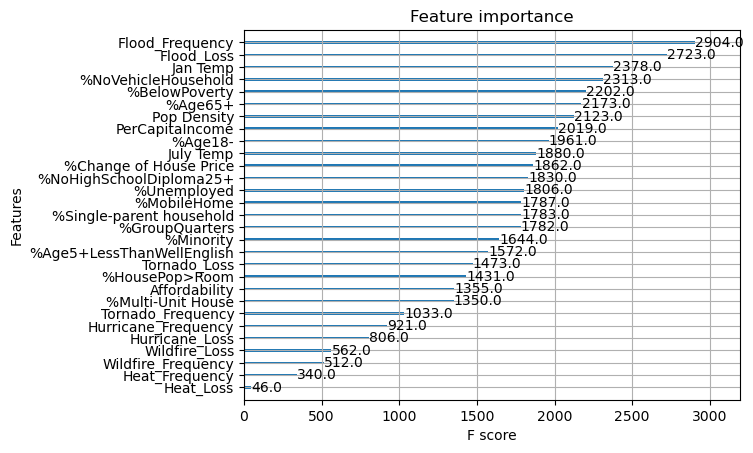

In [151]:
xgb.plot_importance(model)
plt.show()


In [152]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print("Cross-Validation R^2 Scores:", scores)
print("Mean R^2:", scores.mean())

Cross-Validation R^2 Scores: [0.57417509 0.46887181 0.55073194 0.54615469 0.56477225]
Mean R^2: 0.5409411571782734


In [153]:
Regression_data_used.corr()['Flood_Frequency'].sort_values()

%Minority                   -0.148656
Jan Temp                    -0.141834
NMR                         -0.103288
%Age5+LessThanWellEnglish   -0.095117
%HousePop>Room              -0.077295
%Change of House Price      -0.071999
%MobileHome                 -0.056690
%Single-parent household    -0.053500
PerCapitaIncome             -0.051374
Pop Density                 -0.044720
%GroupQuarters              -0.038822
%NoHighSchoolDiploma25+     -0.038156
July Temp                   -0.037611
%Unemployed                 -0.037556
Wildfire_Loss               -0.036448
%Age18-                     -0.031634
%Multi-Unit House           -0.021192
Hurricane_Frequency         -0.011118
Tornado_Loss                -0.007169
FIPS                        -0.005332
Hurricane_Loss              -0.004008
Wildfire_Frequency           0.014778
%BelowPoverty                0.015445
Flood_Loss                   0.022757
%NoVehicleHousehold          0.033551
Affordability                0.059666
%Age65+     

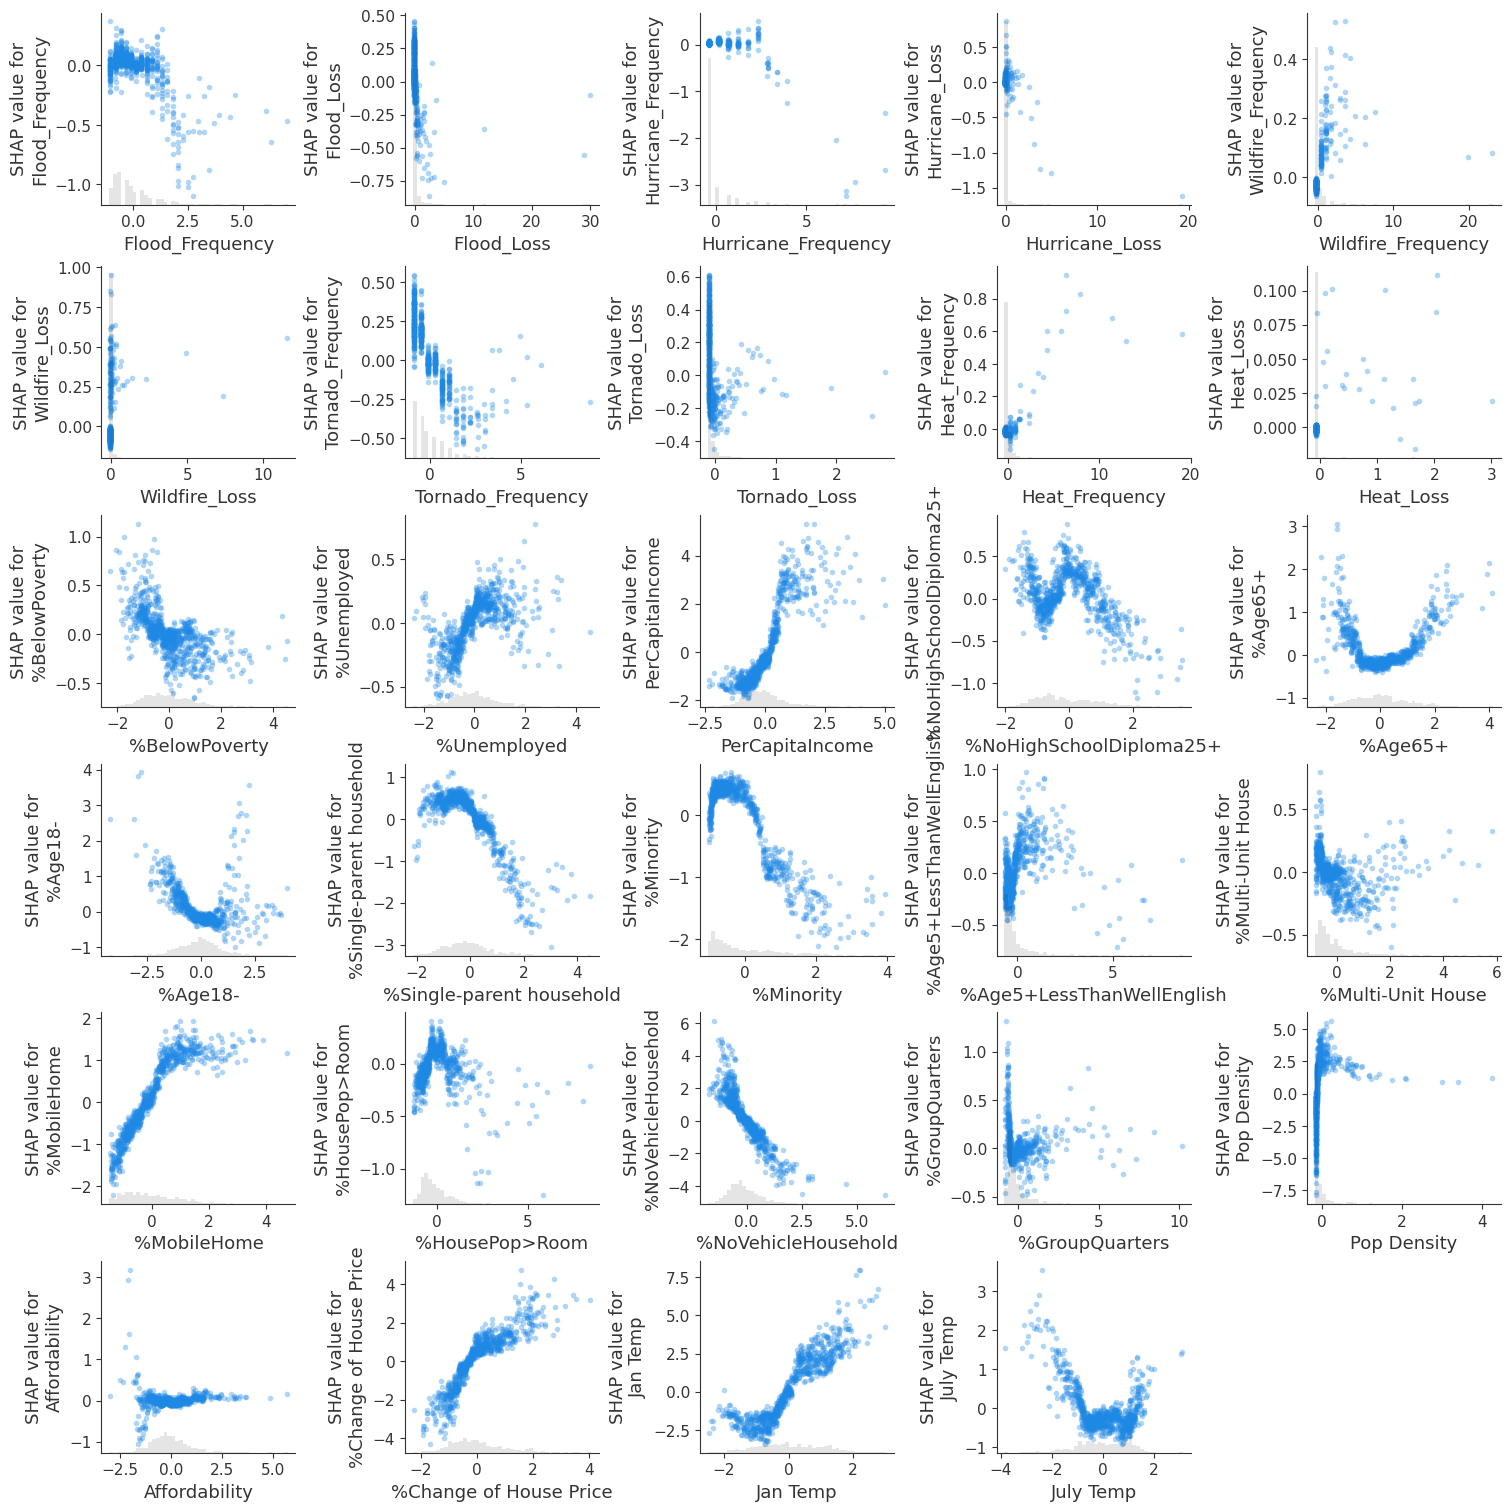

In [165]:
# Define all the features in your dataset
all_features = X_test.columns  # Replace with the features from your test set

# Set up the number of rows and columns for subplots
num_features = len(all_features)
cols = 5  # Number of columns in the subplot grid
rows = (num_features + cols - 1) // cols  # Calculate the number of rows needed

# Create the subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, 15), constrained_layout=True)

# Flatten axes for easy iteration
axes = axes.flatten()

# Generate SHAP dependence plots for each feature
for i, feature in enumerate(all_features):
    shap.plots.scatter(shap_values[:, feature],ax=axes[i], show=False, alpha=0.35)
#     sns.regplot(x=X_test[feature], y=shap_values[:, feature], ax=axes[i], scatter_kws={'s': 10}, line_kws={'color': 'red'})
#     axes[i].set_title(f"SHAP Dependence for {feature}", fontsize=10)
#     shap.dependence_plot(
#         feature, shap_values.values, X_test, ax=axes[i], show=False
#     )
#     axes[i].set_title(f"SHAP Dependence for {feature}", fontsize=10)
    

# Turn off unused subplots if the number of features is less than total subplots
for j in range(len(all_features), len(axes)):
    axes[j].axis("off")

# Show the final figure
plt.show()


In [122]:
from sklearn.linear_model import Lasso
lasso = Lasso(alpha=0.01)
lasso.fit(X, y)

Lasso(alpha=0.01)

In [123]:
import pandas as pd

lasso_coef = pd.Series(lasso.coef_, index=X.columns)

lasso_coef = lasso_coef.sort_values(key=abs, ascending=False)

print(lasso_coef)


Jan Temp                     3.882390
%NoVehicleHousehold         -2.151502
%Change of House Price       1.993817
%Minority                   -1.821421
PerCapitaIncome              1.486116
%MobileHome                  1.025811
%Unemployed                  0.941769
%Multi-Unit House            0.880564
%NoHighSchoolDiploma25+     -0.816363
%Age65+                     -0.725769
%BelowPoverty               -0.645284
Hurricane_Frequency         -0.583924
July Temp                   -0.467478
Pop Density                  0.445647
Hurricane_Loss              -0.420623
Tornado_Loss                -0.298961
Wildfire_Loss               -0.293149
Tornado_Frequency           -0.276751
%Age5+LessThanWellEnglish   -0.272589
Heat_Loss                   -0.225009
Flood_Loss                  -0.175553
%Single-parent household    -0.161867
Wildfire_Frequency          -0.111371
Flood_Frequency             -0.089001
%HousePop>Room              -0.070489
%GroupQuarters               0.064411
Heat_Frequen

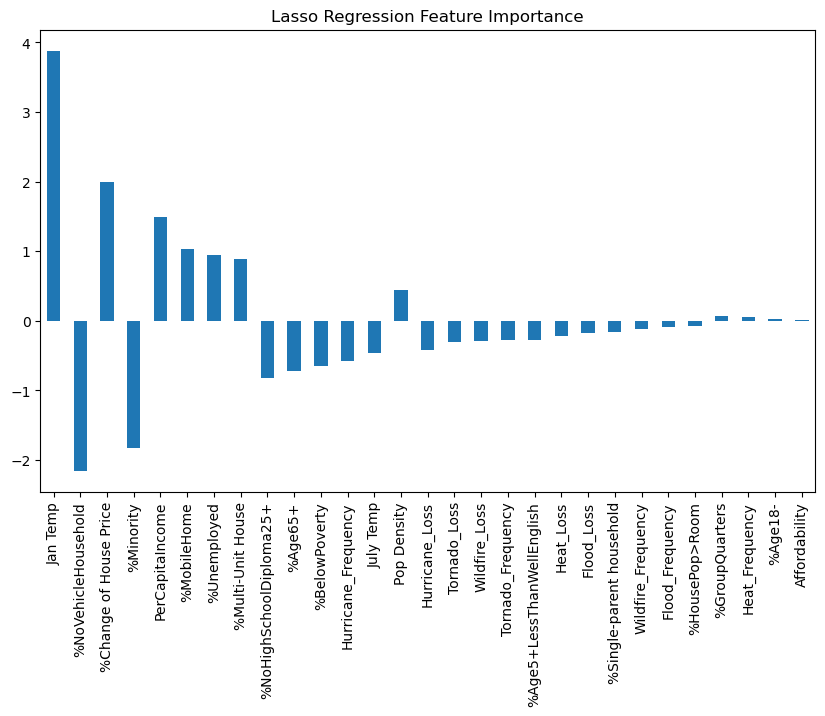

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
lasso_coef.plot(kind="bar")
plt.title("Lasso Regression Feature Importance")
plt.show()

 XGBoost R² Score: -0.0764
Mean Squared Error: 70.39239180159939


 95%|=================== | 724/763 [00:16<00:00]       

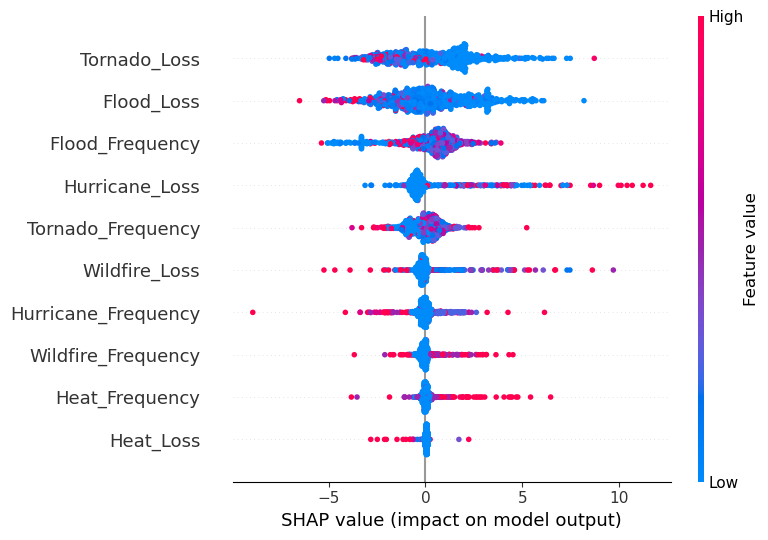

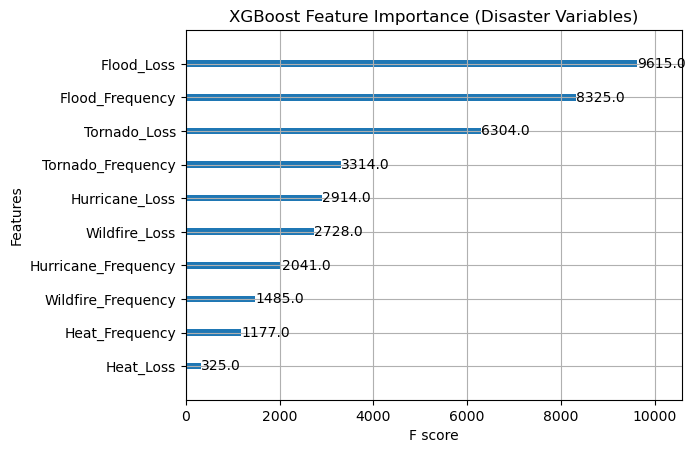

In [166]:
y = Regression_data_used['NMR']
disaster_vars = [col for col in Regression_data_used.columns if 'Flood' in col or 'Hurricane' in col or 'Tornado' in col or 'Wildfire' in col or 'Heat' in col]
X_disaster = Regression_data_used[disaster_vars]

# XGBoost
X_train, X_test, y_train, y_test = train_test_split(X_disaster, y, test_size=0.25, random_state=42)

xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=1000, learning_rate=0.05, max_depth=6, random_state=42)
xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)
xgb_r2 = r2_score(y_test, y_pred)
print(f" XGBoost R² Score: {xgb_r2:.4f}")

# Evaluate the model
y_pred = xgb_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

# Explain the model with SHAP
explainer = shap.Explainer(xgb_model, X_train)
shap_values = explainer(X_test)

# Summary plot of feature importance
shap.summary_plot(shap_values, X_test)

xgb.plot_importance(xgb_model)
plt.title("XGBoost Feature Importance (Disaster Variables)")
plt.show()

In [167]:
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R2: {r2}")

MSE: 70.39239180159939
RMSE: 8.390017389826996
R2: -0.07643994998751524


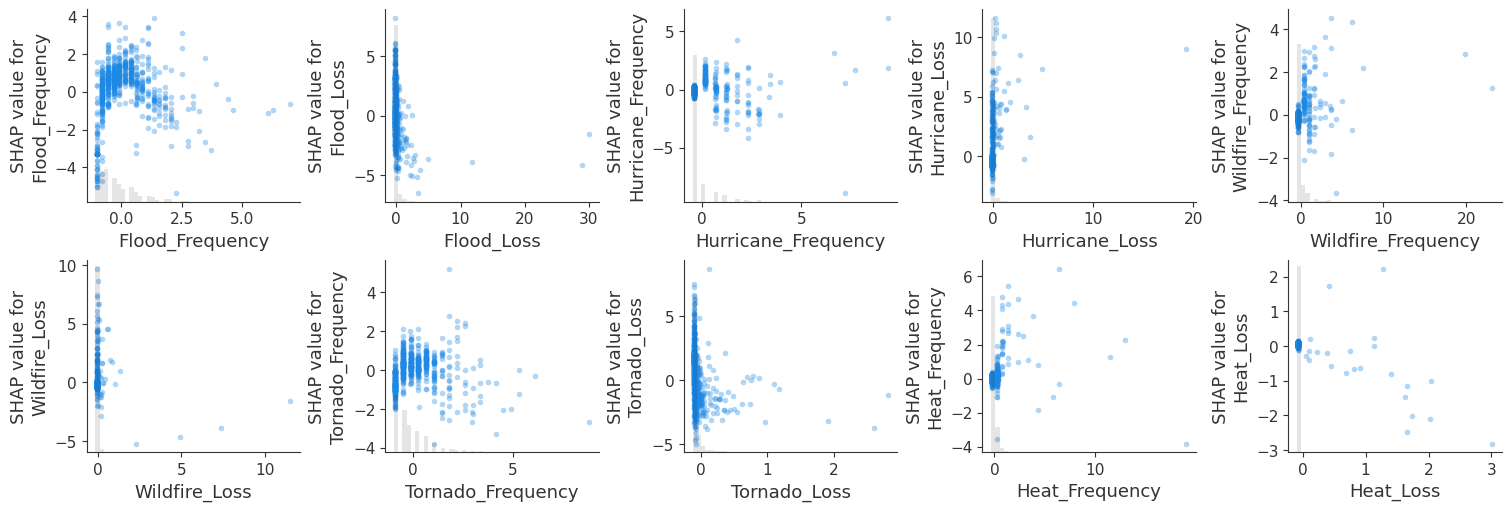

In [168]:
# Define all the features in your dataset
all_features = X_test.columns  # Replace with the features from your test set

# Set up the number of rows and columns for subplots
num_features = len(all_features)
cols = 5  # Number of columns in the subplot grid
rows = (num_features + cols - 1) // cols  # Calculate the number of rows needed

# Create the subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, 5), constrained_layout=True)

# Flatten axes for easy iteration
axes = axes.flatten()

# Generate SHAP dependence plots for each feature
for i, feature in enumerate(all_features):
    shap.plots.scatter(shap_values[:, feature],ax=axes[i], show=False, alpha=0.35)
#     shap.dependence_plot(
#         feature, shap_values.values, X_test, ax=axes[i], show=False
#     )
#     axes[i].set_title(f"SHAP Dependence for {feature}", fontsize=10)
    

# Turn off unused subplots if the number of features is less than total subplots
for j in range(len(all_features), len(axes)):
    axes[j].axis("off")

# Show the final figure
plt.show()


In [169]:
Regression_data_used_ols = Regression_data_used.drop(columns=['FIPS'])

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=['NMR'])

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (All Variables)")
print(model_ols.summary())

# 2 VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print("\nVIF")
print(vif_data)

# OLS (Removed)
high_vif_features = vif_data[vif_data["VIF"] > 5]["Feature"].tolist()
X_filtered = X.drop(columns=high_vif_features)  
X_filtered = sm.add_constant(X_filtered)  

model_ols_filtered = sm.OLS(y, X_filtered).fit()
print("\nOLS（No Collinear Variables）：")
print(model_ols_filtered.summary())

OLS (All Variables)
                            OLS Regression Results                            
Dep. Variable:                    NMR   R-squared:                       0.438
Model:                            OLS   Adj. R-squared:                  0.432
Method:                 Least Squares   F-statistic:                     81.18
Date:                Thu, 06 Mar 2025   Prob (F-statistic):               0.00
Time:                        00:30:48   Log-Likelihood:                -9877.1
No. Observations:                3052   AIC:                         1.981e+04
Df Residuals:                    3022   BIC:                         1.999e+04
Df Model:                          29                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
co

In [170]:
X_ols = sm.add_constant(X_disaster)  # 添加常数项（截距）
model_ols = sm.OLS(y, X_ols).fit()
print("OLS Regression（Only Disaster Variables）：")
print(model_ols.summary())

OLS Regression（Only Disaster Variables）：
                            OLS Regression Results                            
Dep. Variable:                    NMR   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                  0.028
Method:                 Least Squares   F-statistic:                     9.902
Date:                Thu, 06 Mar 2025   Prob (F-statistic):           1.67e-16
Time:                        00:30:51   Log-Likelihood:                -10707.
No. Observations:                3052   AIC:                         2.144e+04
Df Residuals:                    3041   BIC:                         2.150e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------